In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../Sample/Datasets/Sample_master.tsv", sep="\t", encoding="utf-8")
df = df[df["Speaker_role"] != "Chairperson"]
df

,ID,Text,Date,Term,Meeting,Subcorpus,Speaker_role,Speaker_MP,Speaker_minister,Speaker_party,...,Sents,Words,Tokens,Parties,Year,Parlamint,lrgen,galtan,Family,Seat
1,ParlaMint-SI_2019-11-22-SDZ8-Redna-13.u2,"Spoštovani predsednik Državnega zbora, hvala z...",2019-11-22,Term 8,Redna,Reference,Regular,notMP,notMinister,-,...,25,585,646,-,2019,NaN,NaN,NaN,NaN,NaN
3,ParlaMint-SI_2019-11-22-SDZ8-Redna-13.u4,"Spoštovani predsedujoči, kolegice in kolegi! O...",2019-11-22,Term 8,Redna,Reference,Regular,MP,notMinister,LMŠ,...,18,431,467,LMŠ,2019,LMŠ,4.4,4.6,Liberal,14.8
5,ParlaMint-SI_2019-11-22-SDZ8-Redna-13.u6,"Hvala, predsedujoči. Spoštovani! Danes bomo po...",2019-11-22,Term 8,Redna,Reference,Regular,MP,notMinister,SAB,...,16,307,351,ZaAB/ZaSLD/SAB,2019,SAB + ZaSLD,4.2,3.3,No family,5.7
7,ParlaMint-SI_2019-11-22-SDZ8-Redna-13.u8,"Hvala lepa za besedo, gospod predsednik. Spošt...",2019-11-22,Term 8,Redna,Reference,Regular,MP,notMinister,DeSUS,...,15,320,360,DeSUS,2019,DeSUS,3.8,5.1,No family,5.7
9,ParlaMint-SI_2019-11-22-SDZ8-Redna-13.u10,"Predsednik, hvala za besedo. Lep pozdrav vsem ...",2019-11-22,Term 8,Redna,Reference,Regular,MP,notMinister,SNS,...,27,505,583,SNS,2019,SNS,8.7,8.5,Radical Right,4.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5394,ParlaMint-SI_2020-03-04-SDZ8-Redna-16.u214,"Lep pozdrav vsem tistim, ki smo prisotni! Reso...",2020-03-04,Term 8,Redna,COVID,Regular,MP,notMinister,SNS,...,38,533,621,SNS,2020,NaN,NaN,NaN,NaN,NaN
5396,ParlaMint-SI_2020-03-04-SDZ8-Redna-16.u216,"Hvala, podpredsednik, za dano besedo. Cenjeni ...",2020-03-04,Term 8,Redna,COVID,Regular,MP,notMinister,SDS,...,10,217,253,SDS,2020,NaN,NaN,NaN,NaN,NaN
5398,ParlaMint-SI_2020-03-04-SDZ8-Redna-16.u218,"Spoštovani podpredsednik, spoštovani predstavn...",2020-03-04,Term 8,Redna,COVID,Regular,MP,notMinister,LMŠ,...,18,431,488,LMŠ,2020,NaN,NaN,NaN,NaN,NaN
5400,ParlaMint-SI_2020-03-04-SDZ8-Redna-16.u220,Spoštovani vsi prisotni! Naš planet ima zelo j...,2020-03-04,Term 8,Redna,COVID,Regular,MP,notMinister,SD,...,24,526,589,ZLSD/SD,2020,NaN,NaN,NaN,NaN,NaN


## Sample visualisations

In [3]:
df["Date"] = pd.to_datetime(df["Date"])
df["Period"] = (df["Date"] >= "2020-03-13").map({True: "After gov change", False:"Before gov change"})
cols = ["IMNS", "-"]
df = df[~df.isin(cols)]

In [4]:
sentiment_trends = (df.groupby(["Speaker_party", "Period"]).agg(
    mean_sent = ("Senti_n", "mean"),
    count = ("Senti_3", "size")
).reset_index()
)
sentiment_trends

,Speaker_party,Period,mean_sent,count
0,DeSUS,After gov change,2.637667,30
1,DeSUS,Before gov change,1.805096,104
2,LMŠ,After gov change,1.262113,71
3,LMŠ,Before gov change,1.922441,127
4,Levica,After gov change,0.504419,129
5,Levica,Before gov change,0.615601,341
6,NSi,After gov change,2.911290,31
7,NSi,Before gov change,1.270855,152
8,SAB,After gov change,1.660000,42
9,SAB,Before gov change,1.694180,122


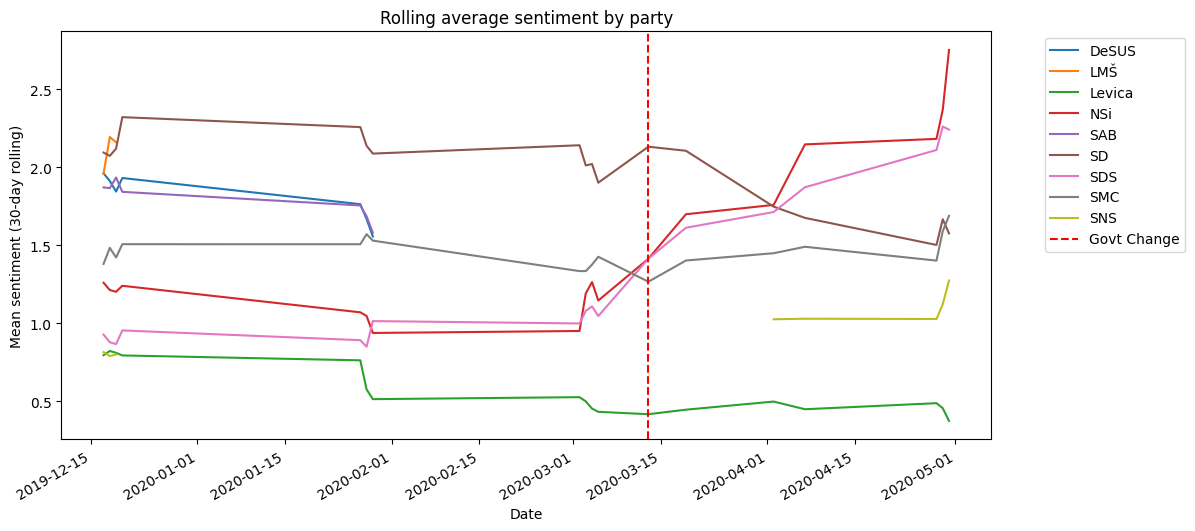

In [5]:
df.groupby(['Date', 'Speaker_party'])['Senti_n'].mean().unstack().rolling(10).mean().plot(figsize=(12,6))
plt.axvline(pd.Timestamp('2020-03-13'), color='red', linestyle='--', label='Govt Change')
plt.title('Rolling average sentiment by party')
plt.ylabel('Mean sentiment (30-day rolling)')
plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
plt.show()

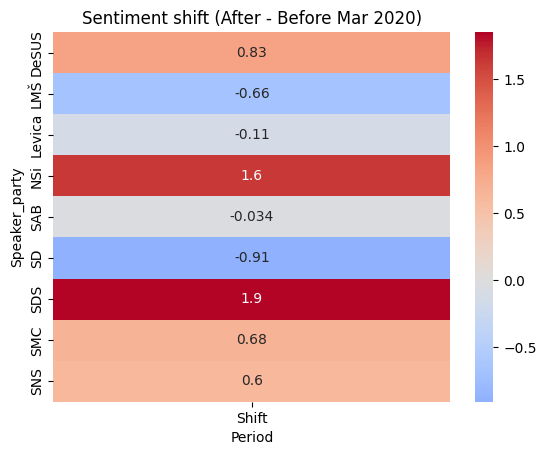

In [6]:
pivot = sentiment_trends.pivot(index='Speaker_party', columns='Period', values='mean_sent')
pivot['Shift'] = pivot['After gov change'] - pivot['Before gov change']

import seaborn as sns
sns.heatmap(pivot[['Shift']], annot=True, cmap='coolwarm', center=0)
plt.title('Sentiment shift (After - Before Mar 2020)')
plt.show()

## Coal-oppo sample

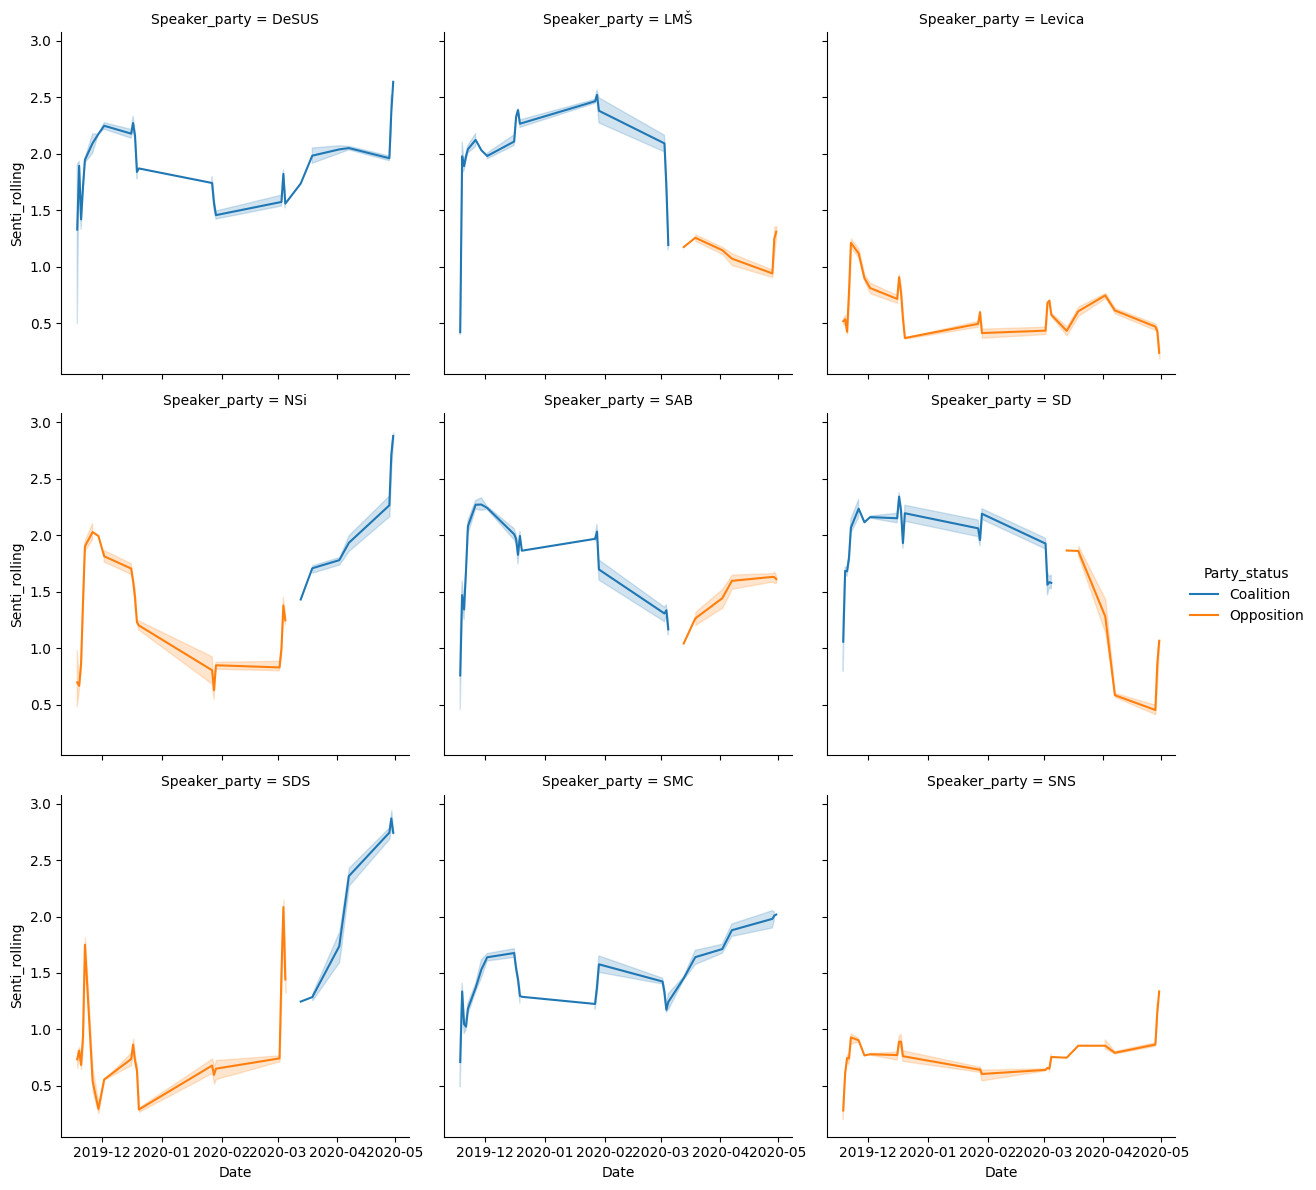

In [7]:
df = df.sort_values(['Speaker_party', 'Date'])

# Compute rolling mean sentiment over last 30 speeches per party
df['Senti_rolling'] = df.groupby('Speaker_party')['Senti_n'].transform(
    lambda x: x.rolling(30, min_periods=1).mean()
)

sns.relplot(
    data=df, x='Date', y='Senti_rolling', hue='Party_status',
    kind='line', col='Speaker_party', col_wrap=3, height=4
)
plt.show()

## Whole dataset only plots

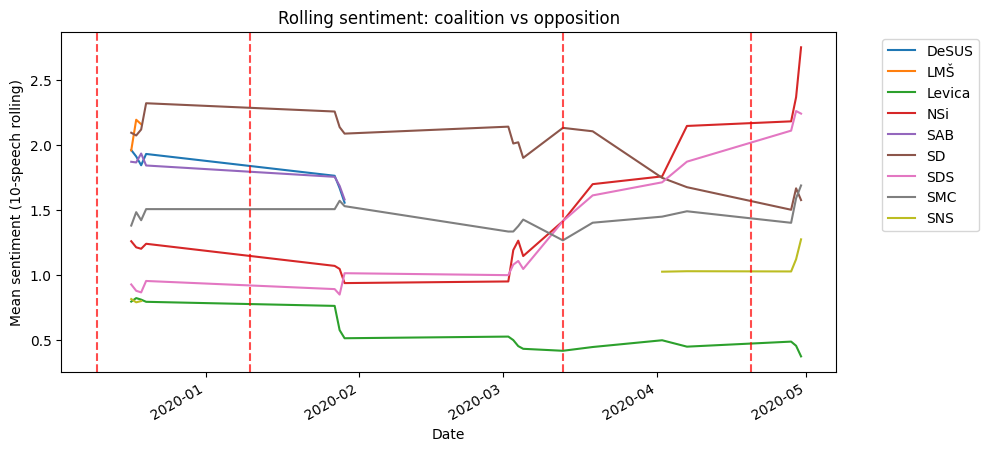

In [8]:
#Dummy gov dates to test for the whole dataset plotting
gov_changes = [
    ('2019-12-10', 'Cerar government'),
    ('2020-01-10', 'Šarec government'),
    ('2020-03-13', 'Janša government'),
    ('2020-04-20', 'Golob government')
]
trend_blocs = (
    df.groupby(['Date','Speaker_party'])['Senti_n']
      .mean().unstack().rolling(10).mean()
)
trend_blocs.plot(figsize=(10,5))
for date, label in gov_changes:
    plt.axvline(pd.Timestamp(date), color='red', linestyle='--', alpha=0.7)
plt.title("Rolling sentiment: coalition vs opposition")
plt.ylabel("Mean sentiment (10-speech rolling)")
plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
plt.show()

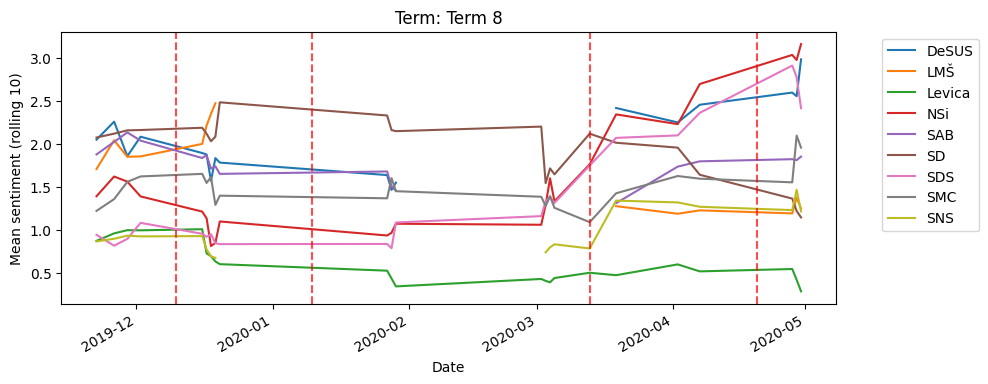

In [9]:
#Individual Term plots (with all government changes in each Term)
for term, sub in df.groupby('Term'):
    trend = sub.groupby(['Date','Speaker_party'])['Senti_n'].mean().unstack().rolling(5).mean()
    trend.plot(figsize=(10,4), title=f"Term: {term}")
    plt.ylabel("Mean sentiment (rolling 10)")
    for date, label in gov_changes:
        if sub['Date'].min() <= pd.Timestamp(date) <= sub['Date'].max():
            plt.axvline(pd.Timestamp(date), color='red', linestyle='--', alpha=0.7)
        plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
    plt.show()

In [10]:
gov_changes = [(pd.Timestamp(d), name) for d, name in gov_changes]
gov_changes

[(Timestamp('2019-12-10 00:00:00'), 'Cerar government'),
 (Timestamp('2020-01-10 00:00:00'), 'Šarec government'),
 (Timestamp('2020-03-13 00:00:00'), 'Janša government'),
 (Timestamp('2020-04-20 00:00:00'), 'Golob government')]

In [11]:
sentiment_shifts = []

for i, (change_date, gov_name) in enumerate(gov_changes):
    prev_date = gov_changes[i-1][0] if i > 0 else df['Date'].min()
    next_date = gov_changes[i+1][0] if i+1 < len(gov_changes) else df['Date'].max()
    
    # Define period window (one year before/after for example)
    before = df[(df['Date'] >= prev_date) & (df['Date'] < change_date)]
    after  = df[(df['Date'] >= change_date) & (df['Date'] < next_date)]
    
    # Compute mean sentiment by party or bloc
    before_mean = before.groupby('Speaker_party')['Senti_n'].mean().rename('Before')
    after_mean  = after.groupby('Speaker_party')['Senti_n'].mean().rename('After')
    
    merged = pd.concat([before_mean, after_mean], axis=1)
    merged['Change'] = merged['After'] - merged['Before']
    merged['Gov_change'] = gov_name
    sentiment_shifts.append(merged.reset_index())

sentiment_shift_df = pd.concat(sentiment_shifts, ignore_index=True)
sentiment_shift_df

,Speaker_party,Before,After,Change,Gov_change
0,DeSUS,1.967200,1.748261,-0.218939,Cerar government
1,LMŠ,1.995385,2.536000,0.540615,Cerar government
2,Levica,0.705865,0.607347,-0.098518,Cerar government
3,NSi,1.501525,1.121081,-0.380444,Cerar government
4,SAB,1.928824,1.924074,-0.004749,Cerar government
5,SD,1.955208,2.193514,0.238305,Cerar government
6,SDS,0.836439,0.633774,-0.202665,Cerar government
7,SMC,1.322857,1.287143,-0.035714,Cerar government
8,SNS,0.773878,0.671364,-0.102514,Cerar government
9,DeSUS,1.748261,1.585806,-0.162454,Šarec government


In [12]:
sentiment_shift_df.pivot_table(
    index='Speaker_party', columns='Gov_change', values='Change'
).round(2)

Gov_change,Cerar government,Golob government,Janša government,Šarec government
Speaker_party,,,,
DeSUS,-0.22,0.57,0.74,-0.16
LMŠ,0.54,0.16,-0.32,-1.00
Levica,-0.10,-0.26,0.16,-0.09
NSi,-0.38,-0.41,1.90,0.01
SAB,-0.00,-0.52,0.61,-0.64
SD,0.24,0.13,-0.74,-0.50
SDS,-0.20,0.65,1.39,0.51
SMC,-0.04,0.23,0.53,0.12
SNS,-0.10,0.34,0.33,0.08


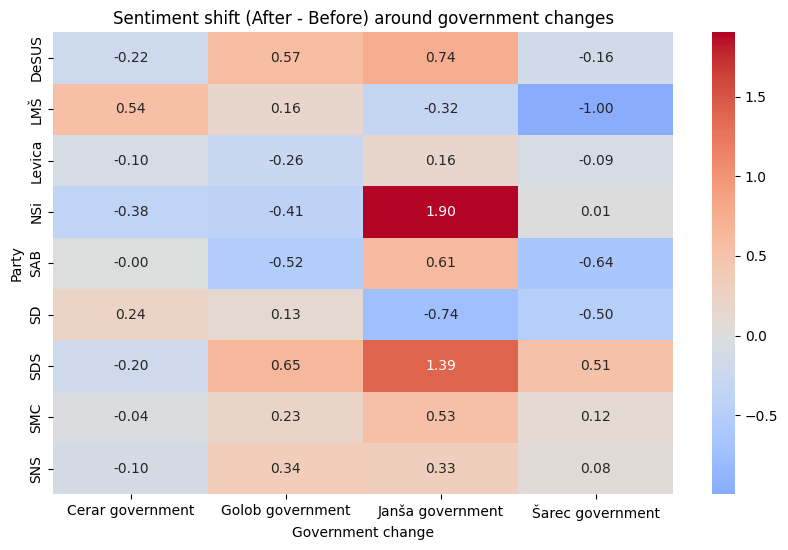

In [13]:
import seaborn as sns
plt.figure(figsize=(10,6))
sns.heatmap(
    sentiment_shift_df.pivot_table(
        index='Speaker_party', columns='Gov_change', values='Change'
    ),
    cmap='coolwarm', center=0, annot=True, fmt=".2f"
)
plt.title('Sentiment shift (After - Before) around government changes')
plt.ylabel('Party')
plt.xlabel('Government change')
plt.show()

## Political orientation sentiment shifts

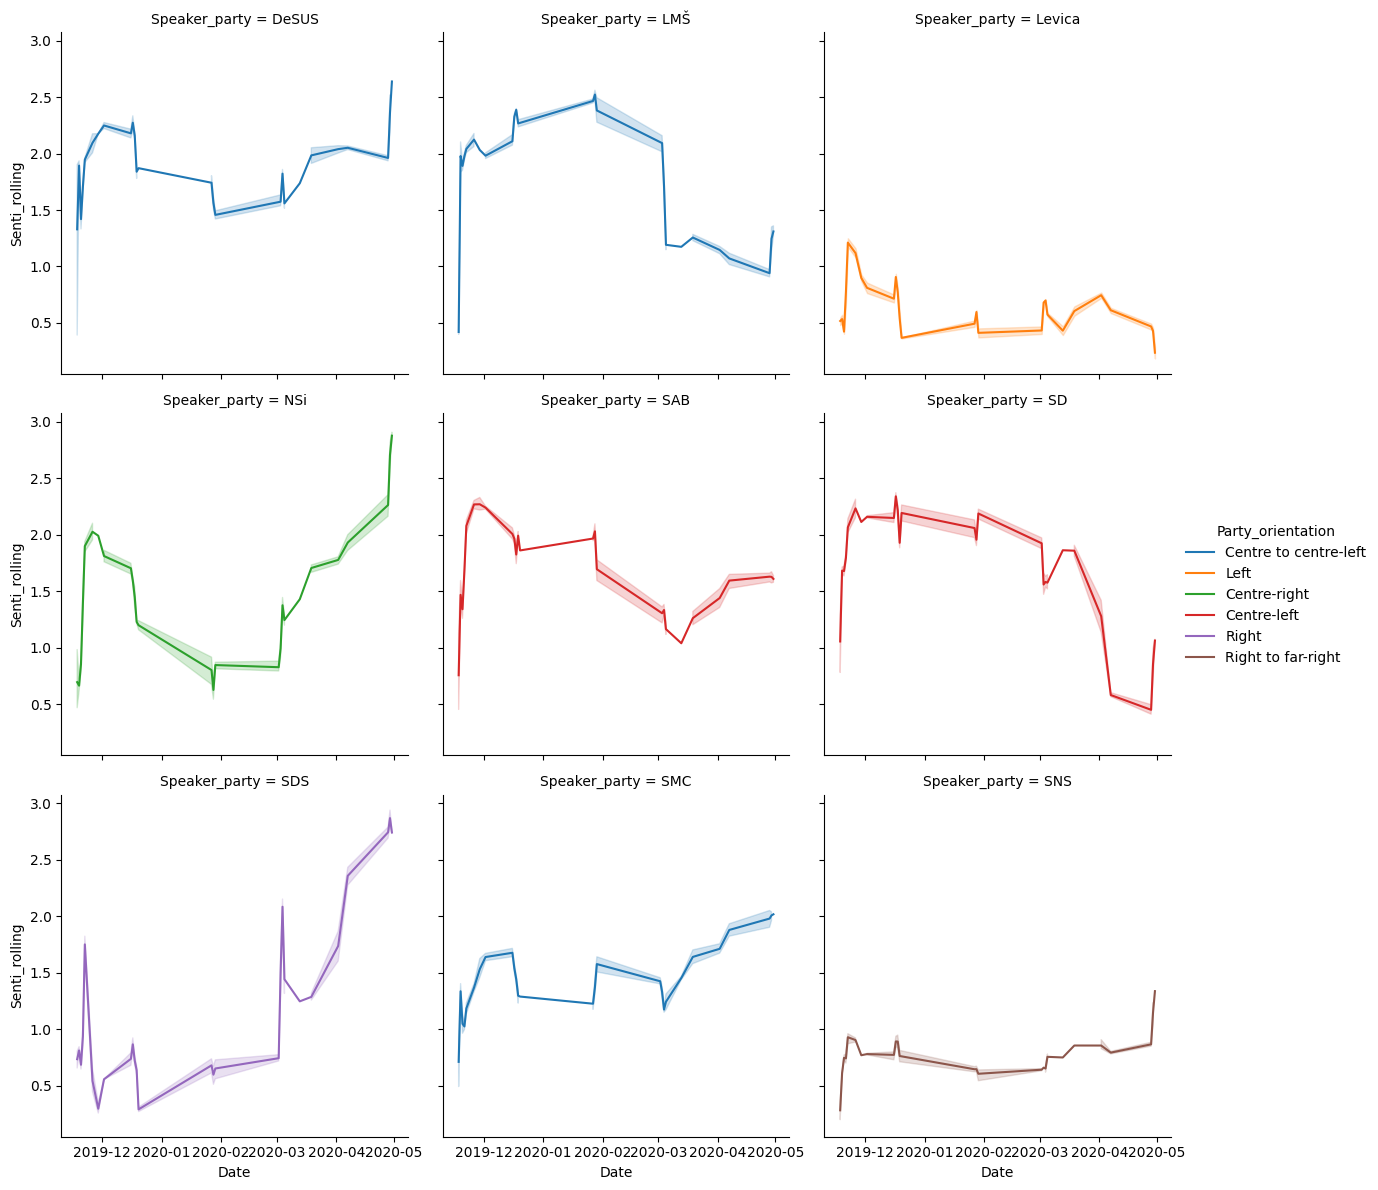

In [14]:
sns.relplot(
    data=df, x='Date', y='Senti_rolling', hue='Party_orientation',
    kind='line', col='Speaker_party', col_wrap=3, height=4
)
plt.show()